# 02 ViT 输入与 Patch Embedding

上一课已经运行了 torchvision 的预训练 ViT，并追踪了完整数据流：

```text
图片
→ patch tokens
→ CLS token + 位置编码
→ Transformer Encoder
→ 分类头
```

现在不急着实现整个 Tiny ViT，而是先把第一步真正拆开：

```text
B x C x H x W 的图片
怎样变成
B x N x D 的 token 序列？
```

这一步叫作 **Patch Embedding**。它是连接“图像张量”和“Transformer token 序列”的桥梁。

## 1. 本课学习目标

完成本课后，需要能够：

1. 独立计算图片会被切成多少个 patch。
2. 区分原始 patch、展平 patch 和 patch token。
3. 解释 Patch Embedding 包含的“切块”和“特征映射”两步。
4. 使用 `unfold` 亲眼检查每个 patch 中包含哪些像素。
5. 使用 `Conv2d(kernel_size=P, stride=P)` 直接得到 patch tokens。
6. 解释一个完整卷积核为什么产生 token 的一个维度。
7. 根据输入通道数、patch_size 和 embed_dim 计算卷积层参数量。
8. 独立实现可用于 Tiny ViT 的 `PatchEmbedding` 模块。
9. 完成一次假损失和反向传播，确认 Patch Embedding 参数可以训练。
10. 解释 patch_size 对 token 数量和 Attention 计算量的影响。

## 2. 为什么必须有 Patch Embedding

CNN 和 Transformer 对输入形状的习惯不同。

CNN 通常接收：

$$
X_{image}:B\times C\times H\times W
$$

Transformer Encoder 通常接收：

$$
X_{tokens}:B\times N\times D
$$

其中：

- $B$：batch size；
- $C$：图片通道数；
- $H,W$：图片高度和宽度；
- $N$：token 数量；
- $D$：每个 token 的特征维度，也叫 embed_dim 或 hidden_dim。

Patch Embedding 的任务不是分类，而是完成形状和表示方式的转换。

## 3. Patch Embedding 实际包含两步

### 第一步：Patchify

把图片切成互不重叠的小块：

```text
整张图片
→ patch 1、patch 2、patch 3、...、patch N
```

### 第二步：Conv2d Projection

使用 `kernel_size=P, stride=P` 的卷积，把每个 patch 映射成长度为 $D$ 的特征向量：

$$
\mathbb{R}^{C\times P\times P}
\longrightarrow
\mathbb{R}^{D}
$$

其中 `out_channels=D`，所以卷积层包含 $D$ 个完整卷积核。每个完整卷积核跨越全部 $C$ 个输入通道，形状是 $C\times P\times P$，负责产生 token 的一个维度。

一个 patch 最终对应一个 patch token。因此：

```text
N 个 patches → N 个 patch tokens
```

并不是所有 patches 合起来只得到一个 token。

## 4. 先掌握通用 shape 公式

假设图片大小是 $H\times W$，patch 大小是 $P\times P$，并且图片尺寸能被 patch_size 整除。

纵向 patch 数量：

$$
N_H=\frac{H}{P}
$$

横向 patch 数量：

$$
N_W=\frac{W}{P}
$$

patch 总数：

$$
N=N_HN_W=\frac{H}{P}\times\frac{W}{P}
$$

每个原始 RGB patch 展平后的长度：

$$
C\times P\times P
$$

经过可学习投影后，每个 patch 变成 $D$ 维 token，最终输出：

$$
B\times N\times D
$$

## 5. 准备实验环境

这一课只使用 PyTorch 和 Matplotlib，不需要下载新依赖或数据集。先固定随机种子，让 Conv2d 的随机参数在重复运行时保持一致。

In [1]:
import matplotlib.pyplot as plt
import torch
from torch import nn

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch：", torch.__version__)
print("计算设备：", device)

PyTorch： 2.10.0
计算设备： cuda


## 6. 用 8 x 8 小图看清 patch

直接从 224 x 224 RGB 图片开始，会被大量像素干扰。这里先构造一张只有一个通道的 8 x 8 小图，像素值从 0 依次增加到 63。

它的形状是：

$$
1\times1\times8\times8
$$

含义是：1 张图片、1 个通道、高 8、宽 8。使用 patch_size=4 后，每行有 2 个 patch，每列有 2 个 patch，因此总共有 4 个 patch。

注意：patch_size = 4，表示每个 patch 是 4x4 像素。在ViT中，通常默认patch是正方形的，所以patch_size=4意味着每个patch的高度和宽度都是4像素。

图片 shape： (1, 1, 8, 8)
图片像素：
 tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.],
        [16., 17., 18., 19., 20., 21., 22., 23.],
        [24., 25., 26., 27., 28., 29., 30., 31.],
        [32., 33., 34., 35., 36., 37., 38., 39.],
        [40., 41., 42., 43., 44., 45., 46., 47.],
        [48., 49., 50., 51., 52., 53., 54., 55.],
        [56., 57., 58., 59., 60., 61., 62., 63.]])


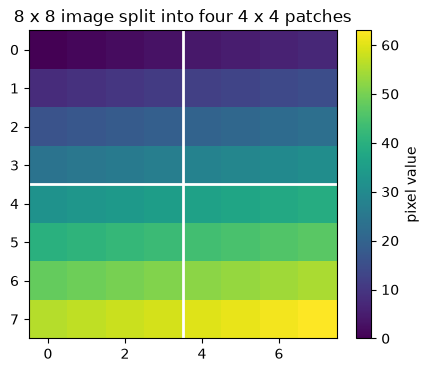

In [3]:
small_image = torch.arange(64, dtype=torch.float32).reshape(1, 1, 8, 8)

print("图片 shape：", tuple(small_image.shape))
print("图片像素：\n", small_image[0, 0])

plt.figure(figsize=(5, 4))
plt.imshow(small_image[0, 0], cmap="viridis")
plt.axhline(3.5, color="white", linewidth=2)
plt.axvline(3.5, color="white", linewidth=2)
plt.colorbar(label="pixel value")
plt.title("8 x 8 image split into four 4 x 4 patches")
plt.show()

## 7. 使用 unfold 亲手切出 patches

`unfold` 可以理解成在某个维度上按窗口取数据。我们会执行两次：

```text
第一次：沿高度维切 4 行一组，步长为 4
第二次：沿宽度维切 4 列一组，步长为 4
```

因为窗口大小和步长都是 4，所以 patches 互不重叠。输出暂时保留 patch 的二维网格位置和 patch 内部结构。

In [4]:
patch_size = 4
patch_grid = small_image.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)

print("patch_grid shape：", tuple(patch_grid.shape))
for row in range(2):
    for col in range(2):
        print(f"\n第 {row * 2 + col + 1} 个 patch，网格位置 ({row}, {col})：")
        print(patch_grid[0, 0, row, col])

patch_grid shape： (1, 1, 2, 2, 4, 4)

第 1 个 patch，网格位置 (0, 0)：
tensor([[ 0.,  1.,  2.,  3.],
        [ 8.,  9., 10., 11.],
        [16., 17., 18., 19.],
        [24., 25., 26., 27.]])

第 2 个 patch，网格位置 (0, 1)：
tensor([[ 4.,  5.,  6.,  7.],
        [12., 13., 14., 15.],
        [20., 21., 22., 23.],
        [28., 29., 30., 31.]])

第 3 个 patch，网格位置 (1, 0)：
tensor([[32., 33., 34., 35.],
        [40., 41., 42., 43.],
        [48., 49., 50., 51.],
        [56., 57., 58., 59.]])

第 4 个 patch，网格位置 (1, 1)：
tensor([[36., 37., 38., 39.],
        [44., 45., 46., 47.],
        [52., 53., 54., 55.],
        [60., 61., 62., 63.]])


### 怎样阅读 unfold 的输出 shape

`patch_grid` 的形状是：

$$
1\times1\times2\times2\times4\times4
$$

六个维度依次表示：

```text
B：1 张图片
C：1 个通道
N_H：纵向 2 个 patch
N_W：横向 2 个 patch
P：patch 内部高度 4
P：patch 内部宽度 4
```

这时还不能直接送入 Transformer，因为 Transformer 想要的是 `B x N x D`，而不是六维张量。

## 8. 把 patch 网格变成 patch 序列

接下来需要完成两件事：

1. 把 $N_H$ 和 $N_W$ 合并成 patch 数量 $N$；
2. 把 $C$、$P$、$P$ 合并成每个原始 patch 的展平长度。

为了让这些维度在内存中按正确顺序排列，先使用 `permute`：

$$
B,C,N_H,N_W,P,P
\longrightarrow
B,N_H,N_W,C,P,P
$$

再使用 `reshape`：

$$
B,N_H,N_W,C,P,P
\longrightarrow
B,N,C P^2
$$

In [7]:
batch_size, channels, grid_h, grid_w, patch_h, patch_w = patch_grid.shape
flat_patches = (
    patch_grid
    .permute(0, 2, 3, 1, 4, 5)
    .contiguous()
    .reshape(batch_size, grid_h * grid_w, channels * patch_h * patch_w)
)

print("展平 patches shape：", tuple(flat_patches.shape))
for index, patch in enumerate(flat_patches[0], start=1):
    print(f"patch {index}：", patch.tolist())

展平 patches shape： (1, 4, 16)
patch 1： [0.0, 1.0, 2.0, 3.0, 8.0, 9.0, 10.0, 11.0, 16.0, 17.0, 18.0, 19.0, 24.0, 25.0, 26.0, 27.0]
patch 2： [4.0, 5.0, 6.0, 7.0, 12.0, 13.0, 14.0, 15.0, 20.0, 21.0, 22.0, 23.0, 28.0, 29.0, 30.0, 31.0]
patch 3： [32.0, 33.0, 34.0, 35.0, 40.0, 41.0, 42.0, 43.0, 48.0, 49.0, 50.0, 51.0, 56.0, 57.0, 58.0, 59.0]
patch 4： [36.0, 37.0, 38.0, 39.0, 44.0, 45.0, 46.0, 47.0, 52.0, 53.0, 54.0, 55.0, 60.0, 61.0, 62.0, 63.0]


### 现在得到 token 了吗

此时形状是：

$$
1\times4\times16
$$

其中 4 表示 4 个 patches，16 表示每个 4 x 4 单通道 patch 展平后有 16 个原始像素值。

它已经具有“序列”的形式，但更准确地说仍是 **展平后的原始 patches**。`unfold` 在这里用于观察每个 patch 包含哪些像素；真正的 ViT 实现会直接对原图使用可学习的 Conv2d，把每个 patch 变成 token。

## 9. 使用 Conv2d 得到 patch tokens

现在回到原始的 $1\times1\times8\times8$ 灰度图，直接使用卷积层：

```python
nn.Conv2d(
    in_channels=1,
    out_channels=6,
    kernel_size=4,
    stride=4,
)
```

这里有 6 个完整卷积核，每个卷积核的形状是 $1\times4\times4$。一个卷积核在一个 patch 上产生一个数字，6 个卷积核共同产生一个 6 维 token。

`stride=4` 让卷积窗口每次正好移动一个 patch，因此同一组 6 个卷积核会依次处理图片中的 4 个 patches。

In [ ]:
embed_dim = 6
conv_projection = nn.Conv2d(
    in_channels=1,
    out_channels=embed_dim,
    kernel_size=patch_size,
    stride=patch_size,
)

conv_feature_map = conv_projection(small_image)
patch_tokens = conv_feature_map.flatten(2).transpose(1, 2)

print("卷积核整体 shape：", tuple(conv_projection.weight.shape))
print("卷积输出 feature map：", tuple(conv_feature_map.shape))
print("patch tokens shape：", tuple(patch_tokens.shape))
print("第一个 patch token：", patch_tokens[0, 0])

### Conv2d Projection 学习的是什么

当前是单通道图片，所以一个完整卷积核包含 $1\times4\times4=16$ 个权重。它完整覆盖一个 patch，并把 16 个像素加权汇总成 token 的一个维度：

$$
y_d=\sum_{i=1}^{4}\sum_{j=1}^{4}W_{d,1,i,j}X_{1,i,j}+b_d
$$

6 个卷积核分别计算 $y_1,y_2,\ldots,y_6$，共同组成一个 6 维 token：

$$
\operatorname{token}=\begin{bmatrix}y_1&y_2&\cdots&y_6\end{bmatrix}
$$

训练过程中，卷积核权重 $W$ 和偏置 $b$ 会通过反向传播更新。因此 token 不是人为指定的边缘、颜色或纹理，而是模型根据分类任务逐渐学习出的 patch 表示。

这里用 6 维只是为了方便观察。真实模型中的 embed_dim 可以小于、等于或大于 $C\times P\times P$。

## 10. 一个卷积核怎样生成 token 的一个维度

以左上角的第一个 patch 和第一个卷积核为例：

$$
\begin{aligned}
\text{第一个 patch}&:1\times4\times4,\\
\text{第一个完整卷积核}&:1\times4\times4.
\end{aligned}
$$

两者对应位置相乘，把全部结果求和，再加第一个 bias，便得到第一个 token 的第一个维度。

同理，第 2～6 个卷积核分别得到这个 token 的第 2～6 维。然后卷积窗口按照 stride 移到下一个 patch，继续使用同一组卷积核。

所以卷积核参数会在所有 patch 位置共享，patch 数量增加不会增加卷积层的参数量。

In [ ]:
first_patch = small_image[:, :, :patch_size, :patch_size]
first_kernel = conv_projection.weight[0:1]
first_bias = conv_projection.bias[0]

manual_value = (first_patch * first_kernel).sum() + first_bias
conv_value = conv_feature_map[0, 0, 0, 0]

print("手动计算的第一个维度：", manual_value.item())
print("Conv2d 输出的第一个维度：", conv_value.item())
print("两者是否一致：", torch.allclose(manual_value, conv_value, atol=1e-6))

### 卷积输出为什么是 B x D x N_H x N_W

卷积直接得到：

$$
1\times6\times2\times2
$$

它仍采用 CNN 的 `B x C x H x W` 排列方式：

```text
1：batch size
6：6 个输出特征，也就是 D
2 x 2：patch 网格
```

Transformer 需要 `B x N x D`，所以再执行：

```text
flatten(2)：B x D x N_H x N_W → B x D x N
transpose(1, 2)：B x D x N → B x N x D
```

最终得到 `1 x 4 x 6`：一张图片有 4 个 patch tokens，每个 token 是 6 维。

这里的 Conv2d 不是经典 CNN 中连续堆叠的特征提取网络。它只使用一次特殊卷积，同时完成“按 patch 移动窗口”和“用多个卷积核生成 token 特征”两件事。

## 11. 扩展到 CIFAR-10 的 Tiny ViT 配置

下一阶段会在 CIFAR-10 上实现 Tiny ViT。建议配置是：

```text
图片：32 x 32 RGB
patch_size：4
embed_dim：192
```

每边 patch 数量：

$$
32/4=8
$$

patch 总数：

$$
N=8\times8=64
$$

所以 Patch Embedding 应把 `B x 3 x 32 x 32` 转成 `B x 64 x 192`。

In [7]:
fake_images = torch.randn(2, 3, 32, 32)
cifar_projection = nn.Conv2d(3, 192, kernel_size=4, stride=4)

cifar_feature_map = cifar_projection(fake_images)
cifar_tokens = cifar_feature_map.flatten(2).transpose(1, 2)

print("输入图片：", tuple(fake_images.shape))
print("卷积输出：", tuple(cifar_feature_map.shape))
print("patch tokens：", tuple(cifar_tokens.shape))

输入图片： (2, 3, 32, 32)
卷积输出： (2, 192, 8, 8)
patch tokens： (2, 64, 192)


### Patch Embedding 有多少参数

一个完整卷积核必须跨越全部 $C$ 个输入通道，并完整覆盖一个 $P\times P$ patch，所以一个卷积核包含：

$$
C\times P\times P\text{ 个权重}+1\text{ 个偏置}.
$$

每个卷积核产生 token 的一个维度。要得到 $D$ 维 token，就需要 $D$ 个完整卷积核，因此 Conv2d 的权重形状是：

$$
D\times C\times P\times P.
$$

再加上每个卷积核各自的一个偏置，也就是 $D$ 个 bias，整个卷积层的参数量是：

$$
D(CP^2+1)=D\times C\times P\times P+D.
$$

代入 CIFAR 配置：

$$
192\times3\times4\times4+192=9408
$$

对 CIFAR 配置来说，一个完整卷积核有 $3\times4\times4=48$ 个权重和 1 个偏置，共 49 个参数；192 维 token 需要 192 个卷积核，所以：

$$
192\times49=9408.
$$

9408 表示这个 Patch Embedding 卷积层中需要训练的参数总数。所有 patch 位置共享这 192 个卷积核，所以参数量不会再乘以 patch 数量。

## 12. 实现可复用的 PatchEmbedding 模块

现在把已经验证过的步骤封装成 `nn.Module`。模块只负责：

```text
检查输入尺寸
→ Conv2d 完成切 patch 和投影
→ flatten 展平 patch 网格
→ transpose 变成 B x N x D
```

这一课暂时不在模块中加入 CLS token 和位置编码，因为它们属于 Patch Embedding 之后的步骤。保持模块职责单一，更容易检查。

In [8]:
class PatchEmbedding(nn.Module):
    def __init__(self, image_size=32, patch_size=4, in_channels=3, embed_dim=192):
        super().__init__()
        if image_size % patch_size != 0:
            raise ValueError("image_size 必须能被 patch_size 整除")

        self.image_size = image_size
        self.patch_size = patch_size
        self.grid_size = image_size // patch_size
        self.num_patches = self.grid_size ** 2
        self.projection = nn.Conv2d(
            in_channels=in_channels,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size,
        )

    def forward(self, x):
        _, _, height, width = x.shape
        if height != self.image_size or width != self.image_size:
            raise ValueError(
                f"期望输入尺寸 {self.image_size} x {self.image_size}，"
                f"实际得到 {height} x {width}"
            )

        x = self.projection(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x

In [9]:
patch_embedding = PatchEmbedding(
    image_size=32,
    patch_size=4,
    in_channels=3,
    embed_dim=192,
)
tokens = patch_embedding(fake_images)

parameter_count = sum(p.numel() for p in patch_embedding.parameters())
print(patch_embedding)
print("grid_size：", patch_embedding.grid_size)
print("num_patches：", patch_embedding.num_patches)
print("参数量：", parameter_count)
print("输入 shape：", tuple(fake_images.shape))
print("输出 shape：", tuple(tokens.shape))

PatchEmbedding(
  (projection): Conv2d(3, 192, kernel_size=(4, 4), stride=(4, 4))
)
grid_size： 8
num_patches： 64
参数量： 9408
输入 shape： (2, 3, 32, 32)
输出 shape： (2, 64, 192)


### 模块输出应该怎样检查

不要只看代码没有报错。至少核对四件事：

1. `grid_size=8`：图片每边被分成 8 个 patch。
2. `num_patches=64`：总共有 64 个 patch tokens。
3. 参数量为 9408：与手算公式一致。
4. 输出是 `2 x 64 x 192`：2 张图片、每张 64 个 token、每个 token 192 维。

输入尺寸检查也很重要。当前 Tiny ViT 配置的位置编码会按 64 个 patch 准备。如果突然输入其他尺寸，token 数量就会变化，后面的位置编码也无法直接相加。

## 13. 验证 Patch Embedding 可以反向传播

Patch Embedding 中的卷积权重需要通过训练学习。现在构造一个没有实际任务含义的假损失，只用来检查计算图是否连通：

$$
loss=mean(tokens^2)
$$

执行 `backward()` 后，如果卷积权重存在非零梯度，就说明后续真实分类 loss 可以沿着网络反向传回 Patch Embedding。

In [10]:
patch_embedding.zero_grad()
tokens = patch_embedding(fake_images)
fake_loss = tokens.square().mean()
fake_loss.backward()

weight_gradient = patch_embedding.projection.weight.grad
print("假损失：", fake_loss.item())
print("权重梯度 shape：", tuple(weight_gradient.shape))
print("梯度范数：", weight_gradient.norm().item())
print("梯度是否全部为 0：", bool(torch.all(weight_gradient == 0)))

假损失： 0.34098637104034424
权重梯度 shape： (192, 3, 4, 4)
梯度范数： 0.09926415234804153
梯度是否全部为 0： False


### 这里验证了什么，没有验证什么

梯度不为 0 说明：

```text
loss
→ patch tokens
→ Conv2d 权重
```

之间的反向传播路径是连通的。

但这并不表示模型已经学会分类。当前 loss 和随机图片都没有真实任务含义。它只是从工程角度验证模块不仅能 forward，也能 backward。

## 14. patch_size 会影响什么

在图片尺寸固定时：

- patch_size 越小，patch 数量越多；
- patch_size 越大，patch 数量越少；
- token 数量 $N$ 会直接影响 Attention 的 $N\times N$ 关系矩阵。

Self-Attention 需要比较 token 两两关系，因此与序列长度相关的主要计算规模是：

$$
N^2
$$

下面固定 CIFAR 图片大小 32 x 32、embed_dim=192，比较不同 patch_size。

In [11]:
image_size = 32
in_channels = 3
embed_dim = 192

print(f"{'patch':>7} {'tokens N':>10} {'N^2':>10} {'projection params':>20}")
for current_patch_size in [2, 4, 8, 16]:
    tokens_n = (image_size // current_patch_size) ** 2
    attention_positions = tokens_n ** 2
    projection_parameters = (
        embed_dim * in_channels * current_patch_size ** 2 + embed_dim
    )
    print(
        f"{current_patch_size:>7} {tokens_n:>10} "
        f"{attention_positions:>10} {projection_parameters:>20}"
    )

  patch   tokens N        N^2    projection params
      2        256      65536                 2496
      4         64       4096                 9408
      8         16        256                37056
     16          4         16               147648


### 怎样解释对比结果

patch_size 从 4 改成 8 时：

```text
token 数量：64 → 16，减少到原来的 1/4
Attention 位置关系：4096 → 256，减少到原来的 1/16
```

这会显著降低 Encoder 的计算量，但每个 token 覆盖更大区域，细粒度信息可能损失。

另一方面，patch 越大，Patch Embedding 单个卷积核包含的参数越多。因此 patch_size 不是简单的“越小越好”或“越大越好”，而是在局部细节、token 数量、Attention 成本和投影参数之间做权衡。

## 15. 常见误解

### 误解一：所有 patches 最后变成一个 token

不是。每个 patch 分别变成一个 token。64 个 patches 得到 64 个 patch tokens。CLS 才是额外增加的特殊 token。

### 误解二：Patch Embedding 使用了完整 CNN

标准 ViT 通常只用一次特殊 Conv2d 实现 patch 投影，没有经典 CNN 中多层 Conv、ReLU 和 Pooling 的特征提取过程。

### 误解三：Patch Embedding 一定是降维

不一定。它把 $C P^2$ 映射到 $D$。$D$ 可以更小、相等或更大。CIFAR 配置中是 `48 → 192`，属于升维。

### 误解四：flatten 后就可以直接进入 Encoder

还要确认形状排列。卷积 flatten 后是 `B x D x N`，必须 transpose 成 `B x N x D`。之后还会加入 CLS token 和位置编码。

### 误解五：切 patch 是不可学习的全部过程

patch 的空间划分规则是固定的，但把 patch 像素映射成 token 的卷积权重是可学习的。

## 16. 本课动手任务

### 任务一：预测 shape 后再运行

把 batch_size 改为 5，先写出 PatchEmbedding 的输出 shape，再运行验证。

### 任务二：修改 patch_size

把 CIFAR 配置的 patch_size 从 4 改成 8，检查 `grid_size`、`num_patches`、输出 shape 和参数量分别怎样变化。

### 任务三：修改 embed_dim

保持 patch_size=4，把 embed_dim 从 192 改成 96。观察 token 数量是否变化，并解释原因。

### 任务四：触发输入检查

新建一个 `2 x 3 x 28 x 28` 假输入传入当前模块，阅读 ValueError。不要删除尺寸检查来绕过错误。

### 任务五：独立重写 forward

不看答案，写出下面三步：`projection → flatten → transpose`，然后用 `torch.allclose` 与当前模块输出对比。

## 17. 本节小结

这份笔记统一使用 Conv2d 实现 Patch Embedding。`unfold` 只帮助我们观察 patch 的内容，不参与最终模块的前向传播。

实际计算路线是：

$$
B\times C\times H\times W
\xrightarrow{\operatorname{Conv2d}(P,P)}
B\times D\times N_H\times N_W
\xrightarrow{\operatorname{flatten+transpose}}
B\times N\times D.
$$

对于 CIFAR-10 Tiny ViT：

$$
B\times3\times32\times32
\rightarrow B\times192\times8\times8
\rightarrow B\times64\times192.
$$

下一课将在 64 个 patch tokens 前加入 CLS token，再加入可学习位置编码，得到 Encoder 真正接收的输入。

### 完成本课后的掌握标准

- 能从图片尺寸和 patch_size 算出 $N$；
- 能说清 $C P^2$ 和 $D$ 的区别；
- 能解释一个 patch 对应一个 token；
- 能看懂 unfold 输出的六个维度；
- 能解释 `flatten(2)` 和 `transpose(1, 2)`；
- 能解释一个完整卷积核为什么产生 token 的一个维度；
- 能计算 Patch Embedding 卷积层的参数量；
- 能独立实现 `PatchEmbedding`；
- 能验证输出 shape、参数量和梯度；
- 能说明 patch_size 对 $N^2$ Attention 成本的影响。

## 18. 自测问题

1. Patch Embedding 为什么是 CNN 图片格式与 Transformer token 格式之间的桥梁？
2. 32 x 32 图片使用 patch_size=4 时，为什么有 64 个 patches？
3. RGB 的 4 x 4 patch 展平后为什么是 48 维？
4. 原始 patch 的 48 维和 token 的 192 维分别由什么决定？
5. 为什么说 CIFAR Tiny ViT 的 `48 → 192` 不是降维？
6. `kernel_size=4, stride=4` 为什么得到互不重叠的 patches？
7. Conv2d 的 `out_channels` 为什么对应 embed_dim？
8. 卷积输出 `B x D x 8 x 8` 怎样转换成 `B x 64 x D`？
9. 为什么 $D$ 维 token 需要 $D$ 个完整卷积核？
10. PatchEmbedding 的卷积参数为什么可以通过分类 loss 更新？
11. patch_size 从 4 改成 8 后，token 数量和 $N^2$ 分别怎样变化？
12. PatchEmbedding 输出中是否已经包含 CLS token 和位置编码？
13. 为什么需要检查输入图片尺寸？
14. batch_size 改变时，$N$ 和 $D$ 会改变吗？
15. patch_size 和 embed_dim 分别控制 token 的哪个方面？

### 自测参考答案

建议先独立回答，再核对关键词。

1. 它把 `B x C x H x W` 图片转换成 Encoder 需要的 `B x N x D`。
2. 每边有 32/4=8 个 patch，总数为 8 x 8=64。
3. RGB 有 3 个通道，所以 $3\times4\times4=48$。
4. 48 由通道数和 patch_size 决定；192 是人为选择的模型特征维度。
5. 输出维度 192 大于输入的 48，属于升维映射。
6. 卷积窗口宽 4，每次也移动 4 个像素，前后窗口不重叠。
7. 每个输出通道由一个卷积核产生一个 patch 特征，所有输出通道共同组成 D 维 token。
8. 先 `flatten(2)` 得到 `B x D x 64`，再 transpose 得到 `B x 64 x D`。
9. 一个完整卷积核在一个 patch 上只产生一个标量；$D$ 个卷积核分别产生 $D$ 个标量，共同组成 $D$ 维 token。
10. 它属于前向计算图，backward 会按照链式法则把梯度传回卷积参数。
11. $N$ 从 64 变成 16，$N^2$ 从 4096 变成 256。
12. 没有。本课模块只输出 patch tokens，CLS 和位置编码在后续加入。
13. 尺寸变化会改变 patch 数量，可能无法与固定长度的位置编码相加。
14. 不会。batch_size 只改变 $B$；$N$ 由图片和 patch_size 决定，$D$ 由 embed_dim 决定。
15. patch_size 主要控制 token 数量和每个 patch 的覆盖范围；embed_dim 控制每个 token 的特征长度。